# Notebook 05: Expanded EEG Biomarker Feature Exploration

**Goal:** compute additional pain-sensitive features from the real ds005284 BDF recordings and make the extractor portable across BIDS EEG sources and channel groups.

This is an exploratory biomarker screen. It does not replace the leakage-safe, LOSO validation in Notebook 04: any feature promoted into a final model must be selected inside each training fold.

Feature families: waveform statistics; AntroPy nonlinear dynamics; PSD and 1/f structure; PyWavelets multiscale energy; librosa MFCCs; Spectrum/Burg autoregression; and pairwise PLV/coherence.

In [1]:
from pathlib import Path
from itertools import combinations
import importlib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal, stats
from scipy.integrate import trapezoid
from sklearn.metrics import roc_auc_score
import mne
import antropy as ant
import pywt

warnings.filterwarnings('ignore')
DATA_ROOT = Path('data/ds005284')
OUT_ROOT = Path('data/preprocessed')
OUT_ROOT.mkdir(parents=True, exist_ok=True)
TASK = '26ByBiosemi'
DEFAULT_CHANNELS = ('C3', 'CZ', 'C4')
TARGET_SFREQ = 256.0

try:
    import librosa
    LIBROSA_AVAILABLE = True
except Exception:
    librosa, LIBROSA_AVAILABLE = None, False
try:
    from spectrum import arburg
    SPECTRUM_AVAILABLE = True
except Exception:
    arburg, SPECTRUM_AVAILABLE = None, False

candidates = {'mne': 'MNE', 'antropy': 'AntroPy', 'pywt': 'PyWavelets', 'spectrum': 'Spectrum', 'librosa': 'librosa', 'mne_connectivity': 'MNE connectivity (optional)', 'neo': 'python-neo (format bridge)', 'invertmeeg': 'invertmeeg (source imaging)', 'best': 'BEST toolbox'}
print('Expanded feature-library status:')
for module, label in candidates.items():
    try:
        version = getattr(importlib.import_module(module), '__version__', 'version unknown')
        print(f'  {label:35s} available ({version})')
    except Exception as exc:
        print(f'  {label:35s} optional/unavailable ({type(exc).__name__})')
print(f'\nReal data root: {DATA_ROOT.resolve()}')
print(f'Default S1 channels: {DEFAULT_CHANNELS}; target sampling rate: {TARGET_SFREQ:g} Hz')

Expanded feature-library status:
  MNE                                 available (1.12.1)
  AntroPy                             available (0.2.2)
  PyWavelets                          available (1.8.0)
  Spectrum                            available (version unknown)
  librosa                             available (0.11.0)
  MNE connectivity (optional)         optional/unavailable (ModuleNotFoundError)
  python-neo (format bridge)          optional/unavailable (ModuleNotFoundError)
  invertmeeg (source imaging)         optional/unavailable (ModuleNotFoundError)
  BEST toolbox                        optional/unavailable (ModuleNotFoundError)

Real data root: /home/runner/workspace/notebooks/data/ds005284
Default S1 channels: ('C3', 'CZ', 'C4'); target sampling rate: 256 Hz


In [2]:
BANDS = {'delta': (1., 4.), 'theta': (4., 8.), 'alpha': (8., 13.), 'beta': (13., 30.), 'low_gamma': (30., 45.)}

def _safe(value):
    value = float(value)
    return value if np.isfinite(value) else 0.0

def _band_power(freqs, psd, low, high):
    mask = (freqs >= low) & (freqs < high)
    return _safe(trapezoid(psd[mask], freqs[mask])) if mask.any() else 0.0

def rename_biosemi_channels(raw, channels_path):
    names = pd.read_csv(channels_path, sep='\t')['name'].astype(str).tolist()
    native = [name for name in raw.ch_names if name.upper() not in {'STATUS', 'TRIGGERS'}]
    if len(native) != len(names):
        raise ValueError(f'Channel mapping mismatch: {len(native)} BDF names vs {len(names)} TSV names')
    raw.rename_channels(dict(zip(native, names)))
    return raw

def load_epochs_for_subject(subject, bids_root=DATA_ROOT, task=TASK, channels=DEFAULT_CHANNELS, target_sfreq=TARGET_SFREQ):
    '''Load actual pain (0-2 s) and pre-stimulus no-pain epochs in microvolts.'''
    eeg_dir = Path(bids_root) / subject / 'eeg'
    stem = eeg_dir / f'{subject}_task-{task}'
    bdf_path, channels_path, events_path = Path(f'{stem}_eeg.bdf'), Path(f'{stem}_channels.tsv'), Path(f'{stem}_events.tsv')
    for path in (bdf_path, channels_path, events_path):
        if not path.exists():
            raise FileNotFoundError(path)
    raw = rename_biosemi_channels(mne.io.read_raw_bdf(str(bdf_path), preload=True, verbose=False), channels_path)
    missing = [channel for channel in channels if channel not in raw.ch_names]
    if missing:
        raise ValueError(f'{subject}: requested channels missing after Biosemi rename: {missing}')
    raw.resample(target_sfreq, npad='auto', verbose=False)
    raw.notch_filter([50., 100.], picks='eeg', verbose=False)
    raw.filter(.5, 80., picks='eeg', verbose=False)
    raw.set_eeg_reference('average', projection=False, verbose=False)
    raw.pick(list(channels))
    event_table = pd.read_csv(events_path, sep='\t')
    pain_onsets = event_table.loc[event_table['value'].eq('condition 54'), 'onset'].to_numpy(float)
    pain_events = np.c_[np.rint(pain_onsets * target_sfreq).astype(int), np.zeros(len(pain_onsets), int), np.ones(len(pain_onsets), int)]
    baseline_events = np.c_[np.rint((pain_onsets - 5.) * target_sfreq).astype(int), np.zeros(len(pain_onsets), int), np.full(len(pain_onsets), 2, int)]
    pain = mne.Epochs(raw, pain_events, event_id={'pain': 1}, tmin=-.2, tmax=2., baseline=(-.2, 0.), reject={'eeg': 200e-6}, preload=True, verbose=False).crop(tmin=0., tmax=2.).get_data()
    no_pain = mne.Epochs(raw, baseline_events, event_id={'no-pain': 2}, tmin=0., tmax=2., baseline=None, reject={'eeg': 200e-6}, preload=True, verbose=False).get_data()
    return np.concatenate([pain, no_pain]) * 1e6, np.r_[np.ones(len(pain), dtype=int), np.zeros(len(no_pain), dtype=int)], float(raw.info['sfreq'])

def channel_features(x, sfreq):
    x = np.nan_to_num(np.asarray(x, dtype=float))
    eps, scale = 1e-12, np.std(x) + 1e-12
    out = {'rms': _safe(np.sqrt(np.mean(x**2))), 'std': _safe(np.std(x)), 'ptp': _safe(np.ptp(x)), 'line_length': _safe(np.mean(np.abs(np.diff(x)))), 'zero_cross_rate': _safe(np.mean(np.diff(np.signbit(x)) != 0)), 'crest_factor': _safe(np.max(np.abs(x)) / scale), 'skew': _safe(stats.skew(x, bias=False)), 'kurtosis': _safe(stats.kurtosis(x, fisher=True, bias=False))}
    activity = np.var(x)
    mobility, complexity = ant.hjorth_params(x)
    out.update({'hjorth_activity': _safe(activity), 'hjorth_mobility': _safe(mobility), 'hjorth_complexity': _safe(complexity), 'sample_entropy': _safe(ant.sample_entropy(x)), 'permutation_entropy': _safe(ant.perm_entropy(x, normalize=True)), 'spectral_entropy': _safe(ant.spectral_entropy(x, sf=sfreq, method='welch', normalize=True)), 'higuchi_fd': _safe(ant.higuchi_fd(x)), 'petrosian_fd': _safe(ant.petrosian_fd(x)), 'dfa': _safe(ant.detrended_fluctuation(x)), 'lziv': _safe(ant.lziv_complexity(x > np.median(x)))} )
    freqs, psd = signal.welch(x, fs=sfreq, nperseg=min(256, len(x)))
    total = _band_power(freqs, psd, 1., 45.) + eps
    for name, (low, high) in BANDS.items():
        power = _band_power(freqs, psd, low, high)
        out[f'{name}_power'], out[f'{name}_relative'] = power, power / total
    valid = (freqs >= 2.) & (freqs <= 40.) & (psd > 0)
    out['aperiodic_slope'] = _safe(np.polyfit(np.log10(freqs[valid]), np.log10(psd[valid]), 1)[0])
    out['spectral_centroid'] = _safe(np.sum(freqs * psd) / (np.sum(psd) + eps))
    cdf = np.cumsum(psd) / (np.sum(psd) + eps)
    out['spectral_edge_50'], out['spectral_edge_95'] = _safe(freqs[np.searchsorted(cdf, .5)]), _safe(freqs[np.searchsorted(cdf, .95)])
    alpha = (freqs >= 8.) & (freqs <= 13.)
    out['alpha_peak_frequency'] = _safe(freqs[alpha][np.argmax(psd[alpha])])
    coeffs = pywt.wavedec(x, 'db4', level=4)
    energies = np.array([np.sum(coeff**2) for coeff in coeffs])
    probs = energies / (energies.sum() + eps)
    for name, value in zip(('approx', 'd4', 'd3', 'd2', 'd1'), probs):
        out[f'wavelet_{name}_relative'] = _safe(value)
    out['wavelet_entropy'] = _safe(-np.sum(probs * np.log(probs + eps)))
    if LIBROSA_AVAILABLE:
        mfcc = librosa.feature.mfcc(y=(x / scale).astype(np.float32), sr=sfreq, n_mfcc=5, n_fft=128, hop_length=64)
        out.update({f'mfcc{i}_mean': _safe(value) for i, value in enumerate(mfcc.mean(axis=1), 1)})
    if SPECTRUM_AVAILABLE:
        try:
            ar, variance, _ = arburg(x / scale, order=8)
            out.update({f'arburg{i}': _safe(value) for i, value in enumerate(np.real(ar[:4]), 1)})
            out['arburg_innovation_variance'] = _safe(variance)
        except Exception:
            out.update({f'arburg{i}': 0. for i in range(1, 5)})
            out['arburg_innovation_variance'] = 0.
    return out

def pair_features(x1, x2, sfreq):
    out = {'correlation': _safe(np.corrcoef(x1, x2)[0, 1]), 'covariance': _safe(np.cov(x1, x2)[0, 1])}
    for name, (low, high) in {'alpha': (8., 13.), 'low_gamma': (30., 45.)}.items():
        sos = signal.butter(4, [low, high], btype='bandpass', fs=sfreq, output='sos')
        phase = np.angle(signal.hilbert(signal.sosfiltfilt(sos, x1))) - np.angle(signal.hilbert(signal.sosfiltfilt(sos, x2)))
        out[f'{name}_plv'] = _safe(abs(np.mean(np.exp(1j * phase))))
        freqs, coh = signal.coherence(x1, x2, fs=sfreq, nperseg=min(256, len(x1)))
        mask = (freqs >= low) & (freqs < high)
        out[f'{name}_coherence'] = _safe(np.mean(coh[mask]))
    return out

def epoch_feature_row(epoch, sfreq, channel_names=DEFAULT_CHANNELS):
    row = {f'{channel}_{name}': value for index, channel in enumerate(channel_names) for name, value in channel_features(epoch[index], sfreq).items()}
    for left, right in combinations(range(len(channel_names)), 2):
        pair_name = f'{channel_names[left]}-{channel_names[right]}'
        row.update({f'{pair_name}_{name}': value for name, value in pair_features(epoch[left], epoch[right], sfreq).items()})
    return row

print('Reusable loader: load_epochs_for_subject(subject, bids_root, task, channels, target_sfreq)')
print('Feature families: waveform + nonlinear + PSD/1-f + wavelet + MFCC + Burg AR + connectivity')

Reusable loader: load_epochs_for_subject(subject, bids_root, task, channels, target_sfreq)
Feature families: waveform + nonlinear + PSD/1-f + wavelet + MFCC + Burg AR + connectivity


In [3]:
# All rows below are derived directly from the 26 downloaded BDF files; no synthetic data is used.
subjects = pd.read_csv(DATA_ROOT / 'participants.tsv', sep='\t')['participant_id'].astype(str).tolist()
rows, failures = [], []
print(f'Extracting expanded features from {len(subjects)} real subjects...')
for index, subject in enumerate(subjects, 1):
    try:
        epochs, labels, sfreq = load_epochs_for_subject(subject)
        for epoch_number, (epoch, label) in enumerate(zip(epochs, labels), 1):
            row = epoch_feature_row(epoch, sfreq)
            row.update({'subject': subject, 'epoch': epoch_number, 'label': int(label), 'label_name': 'pain' if label else 'no-pain'})
            rows.append(row)
        print(f'  [{index:02d}/{len(subjects)}] {subject}: {labels.sum()} pain + {(labels == 0).sum()} no-pain')
    except Exception as exc:
        failures.append((subject, repr(exc)))
        print(f'  FAILED {subject}: {exc}')
if failures:
    raise RuntimeError(f'Real-data extraction failures: {failures}')

biomarker_df = pd.DataFrame(rows)
metadata_columns = {'subject', 'epoch', 'label', 'label_name'}
feature_columns = [column for column in biomarker_df.columns if column not in metadata_columns]
biomarker_df.to_csv(OUT_ROOT / 'biomarker_exploration_features.csv', index=False)
np.savez_compressed(OUT_ROOT / 'biomarker_exploration_features.npz', X=biomarker_df[feature_columns].to_numpy(np.float32), y=biomarker_df.label.to_numpy(np.int64), subjects=biomarker_df.subject.to_numpy(object), feature_names=np.asarray(feature_columns))
print(f'\nExpanded feature matrix: {len(biomarker_df)} epochs x {len(feature_columns)} features')
print(f'Label counts: {biomarker_df.label_name.value_counts().to_dict()}')
print('Saved biomarker_exploration_features.csv and biomarker_exploration_features.npz')

Extracting expanded features from 26 real subjects...


  [01/26] sub-001: 14 pain + 16 no-pain


  [02/26] sub-002: 16 pain + 16 no-pain


  [03/26] sub-003: 16 pain + 16 no-pain


  [04/26] sub-004: 15 pain + 16 no-pain


...

  [23/26] sub-023: 16 pain + 16 no-pain


  [24/26] sub-024: 16 pain + 16 no-pain


  [25/26] sub-025: 16 pain + 15 no-pain


  [26/26] sub-026: 14 pain + 16 no-pain



Expanded feature matrix: 781 epochs x 165 features
Label counts: {'no-pain': 414, 'pain': 367}
Saved biomarker_exploration_features.csv and biomarker_exploration_features.npz


Top 20 expanded biomarkers by absolute Cohen's d:
                      feature cohens_d symmetric_auc mann_whitney_p
                CZ_higuchi_fd   -1.359         0.832      6.203e-58
                CZ_mfcc3_mean    1.354         0.831      1.384e-57
       CZ_wavelet_d1_relative   -1.285         0.839      2.276e-60
       CZ_wavelet_d2_relative   -1.231         0.831      2.280e-57
                       CZ_dfa    1.171         0.803      1.699e-48
                       CZ_rms    1.138         0.812      1.941e-51
           CZ_zero_cross_rate   -1.106         0.783      1.794e-42
                       CZ_ptp    1.091         0.794      1.268e-45
           CZ_hjorth_mobility   -1.031         0.769      1.754e-38
          CZ_spectral_edge_95   -1.031         0.772      2.270e-39
                   CZ_arburg1   -1.031         0.783      1.271e-42
CZ_arburg_innovation_variance   -1.011         0.775      2.517e-40
        CZ_low_gamma_relative   -0.988         0.773      9.348e-4

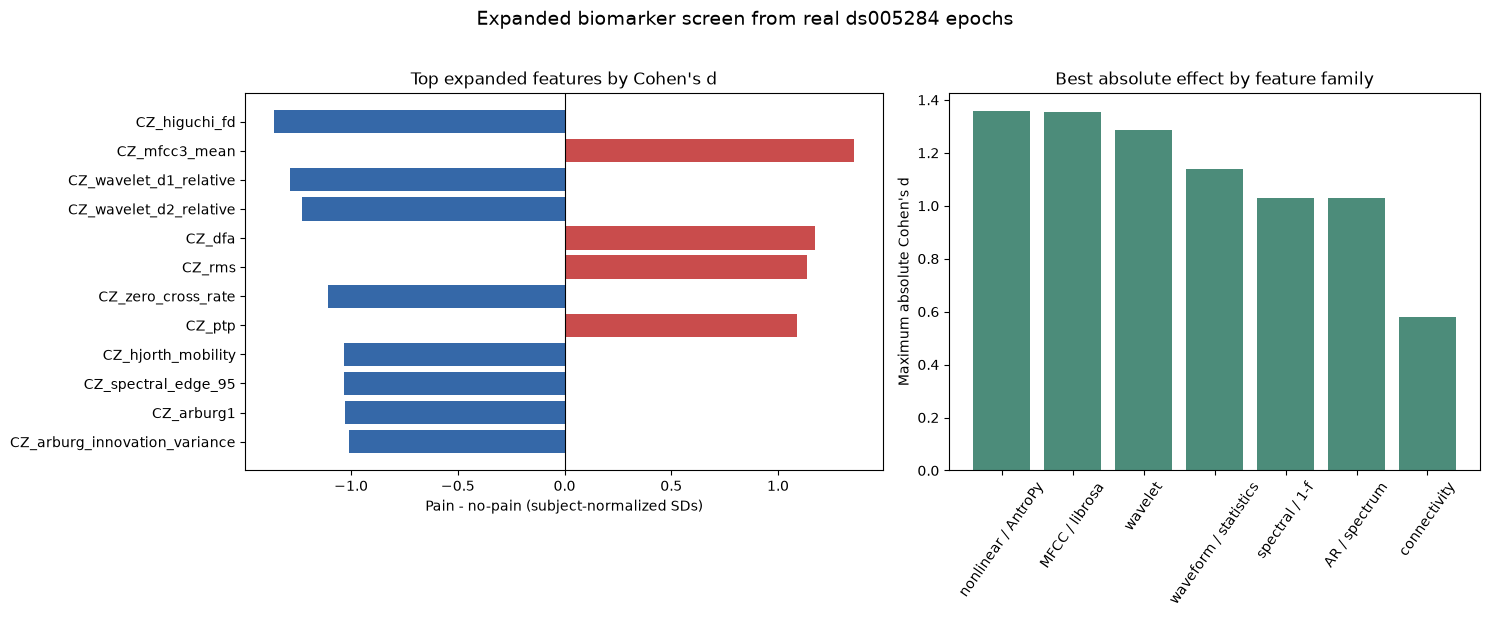

Saved biomarker_exploration_screening.csv and biomarker_exploration_panel.png


In [4]:
# Subject-wise normalization makes this feature screen less sensitive to between-subject amplitude scale.
# It is exploratory only; final selection still belongs inside LOSO folds.
numeric = biomarker_df[feature_columns].replace([np.inf, -np.inf], np.nan).fillna(0.)
normalized = numeric.copy()
for subject, indices in biomarker_df.groupby('subject').groups.items():
    block = numeric.loc[indices]
    normalized.loc[indices] = (block - block.mean()) / (block.std(ddof=0) + 1e-12)
y = biomarker_df.label.to_numpy()
screen_rows = []
for feature in feature_columns:
    values, pain, no_pain = normalized[feature].to_numpy(), normalized.loc[y == 1, feature].to_numpy(), normalized.loc[y == 0, feature].to_numpy()
    pooled = np.sqrt(((len(pain)-1)*np.var(pain, ddof=1) + (len(no_pain)-1)*np.var(no_pain, ddof=1)) / (len(pain)+len(no_pain)-2))
    auc = roc_auc_score(y, values)
    _, p_value = stats.mannwhitneyu(pain, no_pain, alternative='two-sided')
    screen_rows.append({'feature': feature, 'cohens_d': (pain.mean() - no_pain.mean()) / (pooled + 1e-12), 'symmetric_auc': max(auc, 1-auc), 'directional_auc': auc, 'mann_whitney_p': p_value})
screening = pd.DataFrame(screen_rows)
screening['abs_cohens_d'] = screening.cohens_d.abs()
screening = screening.sort_values(['abs_cohens_d', 'symmetric_auc'], ascending=False)
screening.to_csv(OUT_ROOT / 'biomarker_exploration_screening.csv', index=False)
print("Top 20 expanded biomarkers by absolute Cohen's d:")
print(screening[['feature', 'cohens_d', 'symmetric_auc', 'mann_whitney_p']].head(20).to_string(index=False, formatters={'cohens_d': '{:.3f}'.format, 'symmetric_auc': '{:.3f}'.format, 'mann_whitney_p': '{:.3e}'.format}))

def feature_family(name):
    if 'wavelet_' in name: return 'wavelet'
    if 'mfcc' in name: return 'MFCC / librosa'
    if 'arburg' in name: return 'AR / spectrum'
    if any(token in name for token in ('plv', 'coherence', 'correlation', 'covariance')): return 'connectivity'
    if any(token in name for token in ('entropy', 'higuchi', 'petrosian', 'dfa', 'lziv', 'hjorth')): return 'nonlinear / AntroPy'
    if any(token in name for token in ('power', 'relative', 'slope', 'centroid', 'edge', 'peak_frequency')): return 'spectral / 1-f'
    return 'waveform / statistics'
screening['family'] = screening.feature.map(feature_family)
family_summary = screening.groupby('family').agg(features=('feature', 'count'), median_abs_d=('abs_cohens_d', 'median'), best_abs_d=('abs_cohens_d', 'max'), best_auc=('symmetric_auc', 'max')).sort_values('best_abs_d', ascending=False)
print('\nFeature-family screening summary:')
print(family_summary.to_string(formatters={'median_abs_d': '{:.3f}'.format, 'best_abs_d': '{:.3f}'.format, 'best_auc': '{:.3f}'.format}))

top = screening.head(12).sort_values('abs_cohens_d')
fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [1.2, 1]})
axes[0].barh(top.feature, top.cohens_d, color=np.where(top.cohens_d >= 0, '#c94c4c', '#3568a8'))
axes[0].axvline(0, color='black', lw=.8); axes[0].set_title("Top expanded features by Cohen's d"); axes[0].set_xlabel('Pain - no-pain (subject-normalized SDs)')
axes[1].bar(family_summary.index, family_summary.best_abs_d, color='#4c8c7a')
axes[1].set_title('Best absolute effect by feature family'); axes[1].set_ylabel("Maximum absolute Cohen's d"); axes[1].tick_params(axis='x', rotation=55)
fig.suptitle('Expanded biomarker screen from real ds005284 epochs', y=1.02, fontsize=14); fig.tight_layout()
fig.savefig('biomarker_exploration_panel.png', dpi=180, bbox_inches='tight')
plt.show()
print("Saved biomarker_exploration_screening.csv and biomarker_exploration_panel.png")

In [5]:
# The extractor is source/ROI portable: only the channel tuple changes.
source_configs = {'S1 primary analysis': ('C3', 'CZ', 'C4'), 'frontal control ROI': ('F3', 'FZ', 'F4'), 'occipital control ROI': ('O1', 'OZ', 'O2')}
print('Portable source configurations on the real sub-001 recording:')
for name, channels in source_configs.items():
    try:
        demo_epochs, demo_labels, demo_sfreq = load_epochs_for_subject('sub-001', channels=channels)
        demo_features = epoch_feature_row(demo_epochs[0], demo_sfreq, channels)
        print(f'  {name:26s} {channels} -> {demo_epochs.shape[0]} epochs, {len(demo_features)} features, {demo_sfreq:g} Hz')
    except Exception as exc:
        print(f'  {name:26s} unavailable: {exc}')
print('\nTransfer workflow:')
print('  1. Supply a BIDS root with EEG BDF, channels.tsv, and events.tsv.')
print('  2. Call load_epochs_for_subject(..., channels=(...)) or pass an epoch array to epoch_feature_row.')
print('  3. Re-run QC, subject-wise normalization, fold-local feature selection, and LOSO validation for that source.')
print('  4. Treat this screen as hypothesis generation until the feature family improves held-out LOSO AUC.')

Portable source configurations on the real sub-001 recording:


  S1 primary analysis        ('C3', 'CZ', 'C4') -> 30 epochs, 165 features, 256 Hz


  frontal control ROI        ('F3', 'FZ', 'F4') -> 31 epochs, 165 features, 256 Hz


  occipital control ROI      ('O1', 'OZ', 'O2') -> 30 epochs, 165 features, 256 Hz

Transfer workflow:
  1. Supply a BIDS root with EEG BDF, channels.tsv, and events.tsv.
  2. Call load_epochs_for_subject(..., channels=(...)) or pass an epoch array to epoch_feature_row.
  3. Re-run QC, subject-wise normalization, fold-local feature selection, and LOSO validation for that source.
  4. Treat this screen as hypothesis generation until the feature family improves held-out LOSO AUC.
